# Feature Engineering Notebook
This notebook includes a comprehensive pipeline for data preprocessing and feature engineering on the dataset at `data/processed/main/merged.csv`.

### Step 1. Load the merged dataset

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve paths robustly whether kernel CWD is project root or Notebooks/
project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent
input_path = project_root / "data" / "processed" / "main" / "merged.csv"
output_path = project_root / "data" / "processed" / "main" / "feature_engineered.csv"

# Load merged dataset
df = pd.read_csv(input_path, low_memory=False)
print(f"Loaded shape: {df.shape}")
print(f"Input path: {input_path}")
df.head(3)

Loaded shape: (47813, 65)
Input path: c:\Users\RUSHIKESH\Projects\Airbnb Project\data\processed\main\merged.csv


,listing_id,listing_name,listing_type,room_type,cover_photo_url,photos_count,host_id,host_name,cohost_ids,cohost_names,...,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,geographic_zone,distance_from_city_center,city_population
0,1754773.0,Centrally located in Accra with Chocolates to go!,Entire rental unit,entire_home,https://a0.muscache.com/im/pictures/ec7fdf2a-0...,34.0,9220860,Yaaba,NaN,NaN,...,199.7,29.7,304.6,45,31,45,90.0,Africa,1.924028,1963264
1,5059526.0,NEW! Luxury Studio at Embassy Gardens,Entire rental unit,entire_home,https://a0.muscache.com/im/pictures/a1c70987-6...,14.0,26125588,Alex,NaN,NaN,...,146.9,0.0,0.0,17,0,73,90.0,Africa,3.829708,44000
2,5296203.0,Studio Apt. in the center of Osu,Entire bungalow,entire_home,https://a0.muscache.com/im/pictures/68216885/b...,10.0,27429560,Linda,NaN,NaN,...,70.7,12.9,132.5,13,42,77,90.0,Africa,0.423014,44000


### Step 2: Handle Missing Values

In [16]:
df_clean = df.copy()

# Drop highly missing columns
missing_ratio = df_clean.isna().mean()
too_missing_cols = missing_ratio[missing_ratio > 0.50].index.tolist()
df_clean = df_clean.drop(columns=too_missing_cols, errors="ignore")

# Impute missing values
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# Fill numeric columns with median
for col in numeric_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill categorical columns with mode
for col in categorical_cols:
    if df_clean[col].isna().any():
        mode_series = df_clean[col].mode(dropna=True)
        if not mode_series.empty:
            df_clean[col] = df_clean[col].fillna(mode_series.iloc[0])

### Step 3: Drop Leakage and Useless Features

In [17]:
# Drop non-informative and leakage columns
drop_always = [
    'listing_id', 'cover_photo_url', 'host_id', 'host_name', 'listing_name', 'cohost_names', 'currency',
    'city', 'country', 'country_code'
]
drop_l90d = [col for col in df_clean.columns if col.startswith('l90d_')]


# Drop native currency duplicates
drop_native = [col for col in df_clean.columns if col.endswith('_native')] 

# Drop potential leakage columns
drop_leakage = ['ttm_revpar', 'ttm_occupancy', 'ttm_adjusted_occupancy', 'ttm_adjusted_revpar']

# Combine all and drop
cols_to_drop = drop_always + drop_l90d + drop_native + drop_leakage
cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns] 

original_shape = df_clean.shape
df_clean = df_clean.drop(columns=cols_to_drop)

# Drop duplicate columns
df_clean = df_clean.drop_duplicates()

### Step 4: Create Derived Features

In [18]:
import sys
project_root = Path.cwd()
if not (project_root / "scripts").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from scripts.data.main.amenties_utility import create_amenity_features
from scripts.data.main.listing_type_utils import categorize_listing

# Create amenities_count and one-hot encode amenities, then drop original amenities column
amenity_features = create_amenity_features(df_clean['amenities'])
df_clean = pd.concat([df_clean, amenity_features], axis=1)
df_clean = df_clean.drop(columns=['amenities'], errors="ignore")

# Take average of all rating columns to create avg_rating, then drop original rating columns
rating_cols = [
    c for c in df_clean.columns
    if c.startswith("rating_")
]
if rating_cols:
    df_clean["avg_rating"] = df_clean[rating_cols].mean(axis=1, skipna=True)
    df_clean = df_clean.drop(columns=rating_cols, errors="ignore")

# Normalize listing_type into broader categories
df_clean['listing_type'] = df_clean['listing_type'].apply(categorize_listing)

# Add a luxury score based on amenities and listing type
luxury_bonus = 8 
df_clean.loc[df_clean['listing_type'] == 'luxury_unique', 'luxury_score'] += luxury_bonus

### Step 5: Convert Boolean-like Values to 0/1

In [19]:
# Convert boolean-like columns to integers
bool_like_map = {
    "TRUE": 1, "FALSE": 0,
    "true": 1, "false": 0,
    "True": 1, "False": 0,
    True: 1, False: 0,
    "YES": 1, "NO": 0,
    "yes": 1, "no": 0,
    "Y": 1, "N": 0
}

for col in df_clean.columns:
    if df_clean[col].dtype == bool:
        df_clean[col] = df_clean[col].astype(int)
        continue

    if df_clean[col].dtype == object:
        s = df_clean[col].dropna().astype(str).str.strip()
        if len(s) == 0:
            continue
        unique_vals = set(s.unique())
        if unique_vals.issubset({"TRUE", "FALSE", "true", "false", "True", "False", "YES", "NO", "yes", "no", "Y", "N"}):
            df_clean[col] = df_clean[col].map(bool_like_map)

### Step 6: Remove Outliers (After Imputation)

In [20]:
import sys
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from scripts.data.main.outlier_analysis import analyze_outliers_iqr

# Analyze outliers in non-binary numeric features using IQR method
outlier_df = analyze_outliers_iqr(df_clean)
display(outlier_df)

,feature,lower_bound,upper_bound,outlier_count,outlier_pct
0,city_population,-1.121838e+06,1.922694e+06,5843,12.44
1,min_nights,-2.000000e+00,6.000000e+00,5644,12.02
2,ttm_revenue,-2.539075e+04,5.028325e+04,3776,8.04
3,distance_from_city_center,-3.492520e+00,8.192218e+00,3621,7.71
4,bedrooms,-5.000000e-01,3.500000e+00,3344,7.12
5,cleaning_fee,-7.500000e+01,1.250000e+02,3304,7.03
6,rarity_score,-1.980633e-03,6.489305e-03,3274,6.97
7,num_reviews,-1.995000e+02,4.045000e+02,3242,6.90
8,ttm_avg_rate,-1.314000e+02,3.550000e+02,3214,6.84
9,ttm_blocked_days,-9.600000e+01,1.600000e+02,3140,6.69


In [21]:
import numpy as np
import pandas as pd

# Remove rows with invalid negative values in key numeric features
invalid_conditions = (
    (df_clean["min_nights"] < 0) |
    (df_clean["distance_from_city_center"] < 0) |
    (df_clean["cleaning_fee"] < 0) |
    (df_clean["bedrooms"] < 0) |
    (df_clean["beds"] < 0) |
    (df_clean["baths"] < 0) |
    (df_clean["guests"] < 0) |
    (df_clean["num_reviews"] < 0) |
    (df_clean["photos_count"] < 0)
)
df_clean = df_clean[~invalid_conditions].copy()

# Define features and their IQR multipliers for outlier detection
outlier_features = {
    "distance_from_city_center": 3.0,
    "min_nights": 3.0,
    "cleaning_fee": 3.0,
    "bedrooms": 3.0,
    "beds": 3.0,
    "baths": 3.0,
    "num_reviews": 3.0,
    "photos_count": 3.0,
    "ttm_blocked_days": 3.0,
}

# Initialize a boolean Series to keep track of rows to retain
rows_to_keep = pd.Series([True] * len(df_clean), index=df_clean.index)

# Apply IQR-based outlier detection and mark rows to remove
for col, iqr_mult in outlier_features.items():
    if col not in df_clean.columns:
        continue
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:
        continue

    lower_bound = Q1 - iqr_mult * IQR
    upper_bound = Q3 + iqr_mult * IQR

    outlier_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    outlier_count = outlier_mask.sum()
    outlier_pct = 100 * outlier_count / len(df_clean)
    rows_to_keep = rows_to_keep & ~outlier_mask

df_before = len(df_clean)
df_clean = df_clean[rows_to_keep].copy()
rows_removed = df_before - len(df_clean)
rows_pct_removed = 100 * rows_removed / df_before
print(df_clean["ttm_avg_rate"].describe())

count    37643.000000
mean       126.987703
std        125.688928
min          8.600000
25%         49.000000
50%         90.800000
75%        162.600000
max       3525.000000
Name: ttm_avg_rate, dtype: float64


In [22]:
outlier_df = analyze_outliers_iqr(df_clean)
display(outlier_df)

,feature,lower_bound,upper_bound,outlier_count,outlier_pct
0,baths,2.500000e-01,2.250000e+00,8819,23.43
1,city_population,-1.279906e+06,2.190018e+06,4050,10.76
2,ttm_revenue,-2.407825e+04,4.797575e+04,2831,7.52
3,ttm_blocked_days,-8.250000e+01,1.375000e+02,2689,7.14
4,rarity_score,-1.877884e-03,6.298679e-03,2526,6.71
5,distance_from_city_center,-3.256476e+00,7.828485e+00,2275,6.04
6,cleaning_fee,-6.900000e+01,1.150000e+02,2257,6.00
7,num_reviews,-1.995000e+02,4.125000e+02,2073,5.51
8,ttm_avg_rate,-1.214000e+02,3.330000e+02,2051,5.45
9,bedrooms,-5.000000e-01,3.500000e+00,1705,4.53


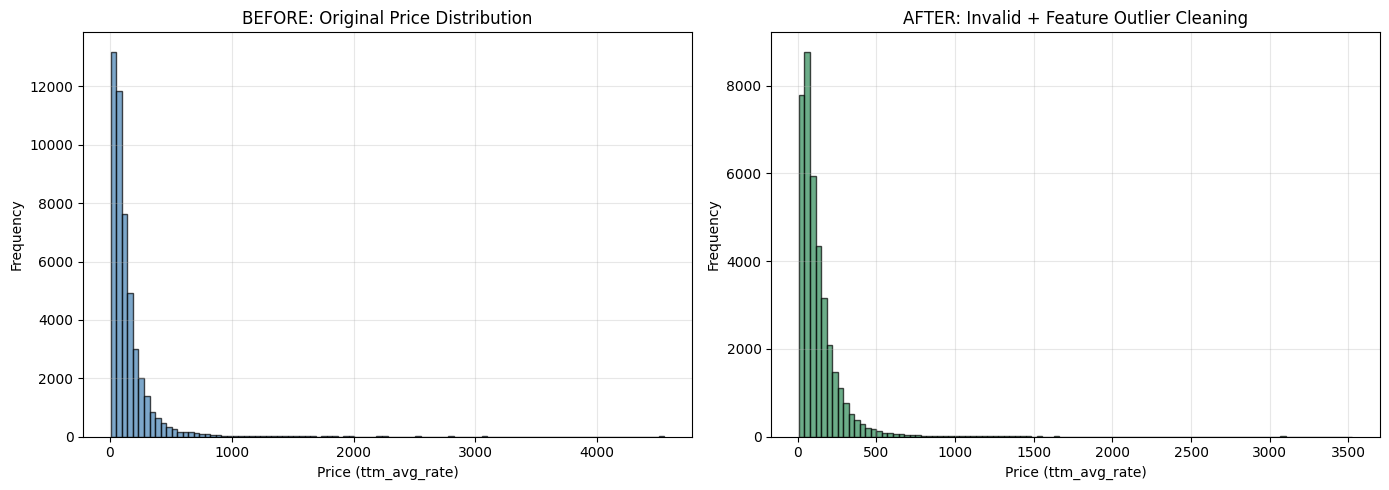

In [23]:
# Visualize target distribution before vs after Step 5 (without target hard cutoff)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original data
axes[0].hist(df['ttm_avg_rate'], bins=100, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Price (ttm_avg_rate)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('BEFORE: Original Price Distribution')
axes[0].grid(True, alpha=0.3)

# After cleaning
axes[1].hist(df_clean['ttm_avg_rate'], bins=100, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('Price (ttm_avg_rate)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('AFTER: Invalid + Feature Outlier Cleaning')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 7: Encoding Categorical Features

In [24]:
# Use the cleaned dataframe before one-hot encoding
source_df = df_clean if "df_clean" in globals() else df_clean

# Identify categorical columns for encoding
categorical_cols = source_df.select_dtypes(include=["object", "category", "string"]).columns.tolist()
unique_counts = source_df[categorical_cols].nunique(dropna=False).sort_values(ascending=False)

df_encoded = df_clean.copy()

# Ordinal Encoding — cancellation_policy
cancellation_order = {
    'Full Refundable Until Check-in': 0,
    'Full Refundable Until 24 Hours Before Check-in': 1,
    'Full Refundable Until 72 Hours Before Check-in': 2,
    'Refundable': 3,
    'Flexible': 4,
    'Moderate': 5,
    'Limited': 6,
    'Firm': 7,
    'Strict': 8,
    'Non-refundable': 9,
    'Super Strict 30 Days': 10,
    'Super Strict 60 Days': 11
}
df_encoded['cancellation_policy'] = df_encoded['cancellation_policy'].str.strip().map(cancellation_order)

# One-Hot Encoding — geographic_zone, room_type
df_encoded = pd.get_dummies(df_encoded, columns=['listing_type', 'room_type', 'geographic_zone'])

# Verify
print(df_encoded.shape)
print(df_encoded.dtypes[df_encoded.dtypes == 'object']) 

(37643, 64)
Series([], dtype: object)


### Step 8: Applying Transformations

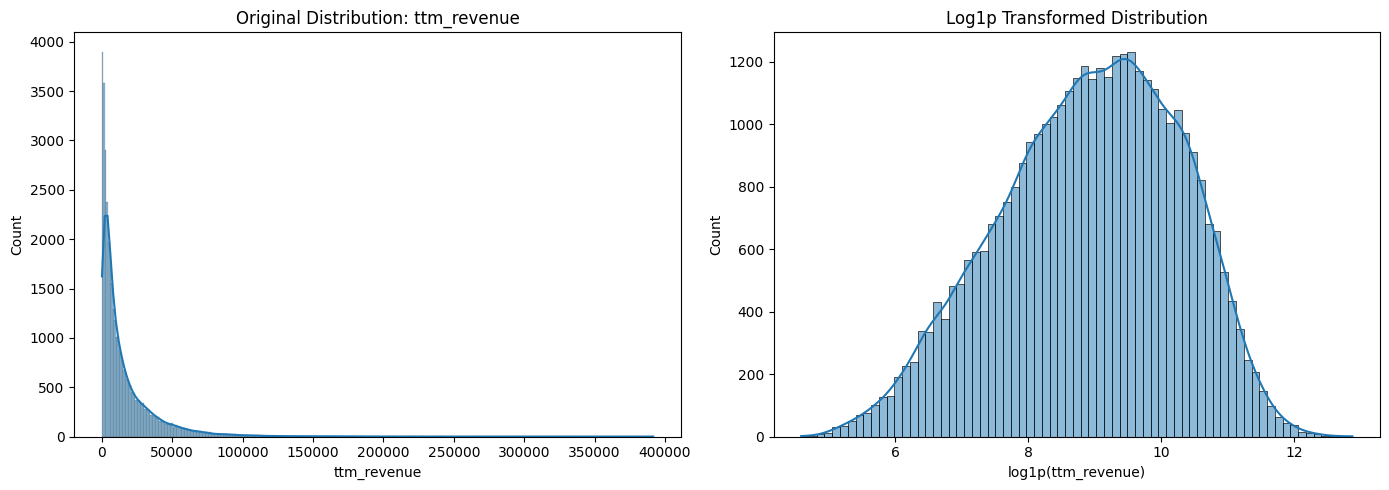

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Original data
original_data = df_encoded['ttm_revenue'].dropna()

# Log1p transformed data
log_transformed_data = np.log1p(original_data)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
sns.histplot(original_data, kde=True, ax=axes[0])
axes[0].set_title('Original Distribution: ttm_revenue')
axes[0].set_xlabel('ttm_revenue')

# Log1p transformed distribution
sns.histplot(log_transformed_data, kde=True, ax=axes[1])
axes[1].set_title('Log1p Transformed Distribution')
axes[1].set_xlabel('log1p(ttm_revenue)')

plt.tight_layout()
plt.show()

In [11]:
import numpy as np

# Log-transform skewed numeric features to reduce outlier impact 
log_cols = [
    'ttm_avg_rate',
    'ttm_revenue',
    'num_reviews', 
    'distance_from_city_center',
]

for col in log_cols:
    if col in df_encoded.columns:
        df_encoded[col] = np.log1p(df_encoded[col]) 

### Step 9: Correlation Analysis
- Drop highly correlated features to reduce redundancy
- Plot a correlation heatmap on the top-variance numeric features in the final engineered dataset for readability.

In [12]:
corr_matrix = df_encoded.select_dtypes(include=[np.number]).corr().abs()

# Find all pairs with correlation > 0.7
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row) for col in upper.columns 
             for row in upper.index 
             if upper[col][row] > 0.7]

print(high_corr)

[('bedrooms', 'guests'), ('beds', 'guests'), ('ttm_reserved_days', 'ttm_revenue'), ('ttm_available_days', 'ttm_revenue'), ('ttm_available_days', 'ttm_reserved_days'), ('has_pool', 'luxury_score')]


In [13]:
# Drop highly correlated features
drop_correlated = ['ttm_revpar', 'ttm_available_days', 'ttm_reserved_days']
df_encoded = df_encoded.drop(columns=drop_correlated, errors='ignore')

### Step 10. Save the feature engineered dataset

In [14]:
df_encoded.to_csv(output_path, index=False)
print(f"Final engineered shape: {df_encoded.shape}")
df_encoded.head(3)

Final engineered shape: (37643, 62)


,photos_count,superhost,latitude,longitude,guests,bedrooms,beds,baths,registration,professional_management,...,room_type_entire_home,room_type_hotel_room,room_type_private_room,room_type_shared_room,geographic_zone_Africa,geographic_zone_Asia Pacific,geographic_zone_Europe,geographic_zone_Latin America,geographic_zone_Middle East,geographic_zone_Northern America
0,34.0,1,5.5733,-0.1960,2.0,1.0,1.0,1.5,0,0,...,True,False,False,False,True,False,False,False,False,False
1,14.0,0,5.5860,-0.1673,2.0,2.0,2.0,1.0,0,0,...,True,False,False,False,True,False,False,False,False,False
2,10.0,1,5.5610,-0.1856,2.0,1.0,1.0,1.0,0,0,...,True,False,False,False,True,False,False,False,False,False
